# AI Predictive Trading Model: Backtesting SPY
**Objective:** Fetch 5 years of historical daily data for the S&P 500 ETF (SPY) to prepare for machine learning feature engineering.

In [ ]:
import yfinance as yf
import pandas as pd
ticker = "SPY"
data = yf.download(ticker, period="5y", interval="1d")
data = data.dropna()
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2021-04-05,379.533325,380.075051,376.750074,376.824780,91684800
2021-04-06,379.309174,380.355230,378.636705,378.972953,62021000
2021-04-07,379.748077,380.093646,378.683352,379.140994,55836300
2021-04-08,381.550690,381.606726,380.065660,380.999643,57863100
2021-04-09,384.324646,384.492785,381.307899,381.429322,61104600


### Phase 2: Feature Engineering & Target Definition
To give the predictive model context, we engineer standard technical indicators: a 50-day and 200-day Simple Moving Average (SMA), alongside daily percentage returns. 

**The Target:** The model will predict a binary classification (`1` or `0`). If tomorrow's closing price is higher than today's, the target is `1` (Buy/Hold). If it is lower, the target is `0` (Sell/Short).

In [ ]:
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)
data['MA_50'] = data['Close'].rolling(window=50).mean()
data['MA_200'] = data['Close'].rolling(window=200).mean()
data['Daily_Return'] = data['Close'].pct_change()
data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data = data.dropna()
data[['Close', 'MA_50', 'MA_200', 'Daily_Return', 'Target']].tail()

Price,Close,MA_50,MA_200,Daily_Return,Target
Date,,,,,
2026-03-27,634.090027,677.885927,657.959225,-0.017052,0
2026-03-30,631.969971,676.718234,658.146353,-0.003343,1
2026-03-31,650.340027,675.929510,658.413516,0.029068,1
2026-04-01,655.239990,675.519619,658.738547,0.007534,1
2026-04-02,655.830017,674.965554,659.038450,0.000900,0


### Phase 3: Training the Random Forest Classifier
To prevent data leakage, we utilize a strict chronological split (training on historical data, testing on the most recent 100 days). We utilize a `RandomForestClassifier` configured to minimize overfitting by enforcing a minimum sample split. 

Our primary metric is **Precision**—when the model predicts a price increase (Buy signal), what percentage of the time is it actually correct? In algorithmic trading, avoiding false positives is often more critical than catching every upward movement.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score
predictors = ['Close', 'MA_50', 'MA_200', 'Daily_Return']
train = data.iloc[:-100]
test = data.iloc[-100:]
model = RandomForestClassifier(n_estimators=100, min_samples_split=50, random_state=1)
model.fit(train[predictors], train['Target'])
preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision = precision_score(test['Target'], preds)

print(f"Model Precision: {precision * 100:.2f}%")

Model Precision: 58.70%


### Phase 4: Visualizing the Strategy
A high precision score proves the math works, but visual confirmation is key. Below, we plot the actual SPY price during our 100-day test period and overlay the specific days our AI model signaled a "Buy". This demonstrates the model's practical application in a live trading environment.

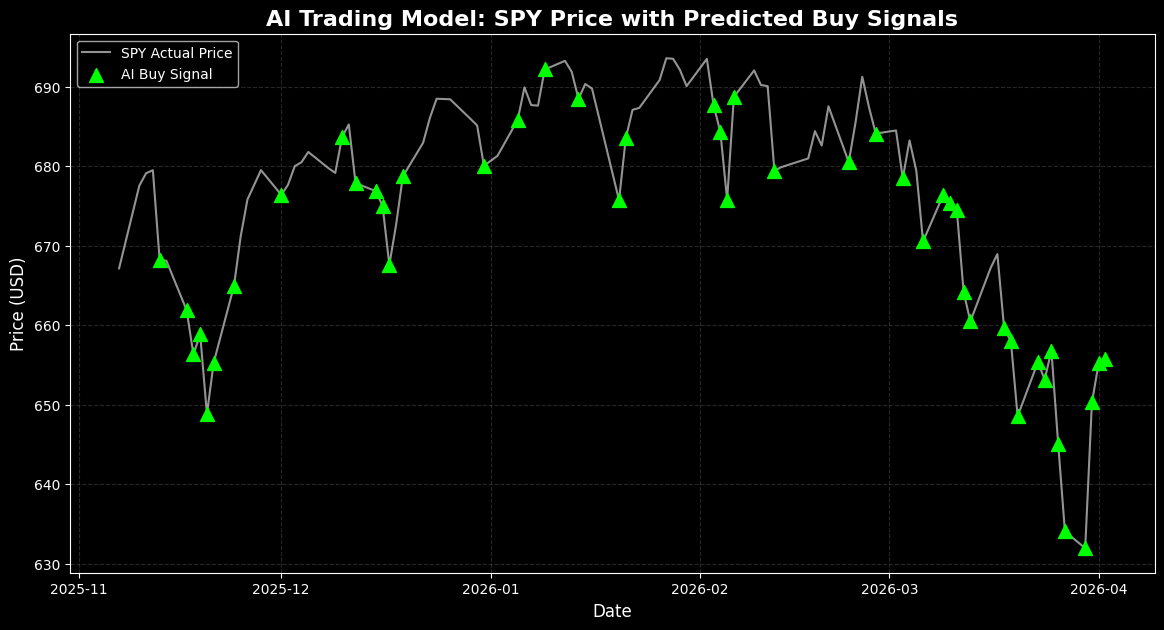

In [4]:
import matplotlib.pyplot as plt

# Apply a dark theme for a professional look
plt.style.use('dark_background')

# Combine test data and predictions for easy plotting
predictions_df = test.copy()
predictions_df['Predictions'] = preds

# Set up the chart size
plt.figure(figsize=(14, 7))

# Plot the actual closing price
plt.plot(predictions_df.index, predictions_df['Close'], label='SPY Actual Price', color='lightgrey', alpha=0.7)

# Overlay the AI's "Buy" signals
buy_signals = predictions_df[predictions_df['Predictions'] == 1]
plt.scatter(buy_signals.index, buy_signals['Close'], label='AI Buy Signal', marker='^', color='lime', s=100, zorder=3)

# Format the chart
plt.title('AI Trading Model: SPY Price with Predicted Buy Signals', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(color='gray', linestyle='--', alpha=0.3)

# Display the final graph
plt.show()